In [1]:
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

In [2]:
# 1. Load the Iris Dataset
# -------------------------------------------------------------

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Convert species numbers to names for clarity
species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
df['species'] = df['species'].map(species_map)

print("Full Dataset:")
display(df.head())

Full Dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# 2. Simple Random Sampling (10% of the data)
# -------------------------------------------------------------

simple_sample = df.sample(frac=0.10, random_state=42)

print("\nSimple Random Sample (10%):")
display(simple_sample.head())

# Species distribution in population vs sample
population_dist = df['species'].value_counts(normalize=True)
simple_dist = simple_sample['species'].value_counts(normalize=True)

print("\nPopulation Species Distribution:")
print(population_dist)

print("\nSimple Random Sample Species Distribution:")
print(simple_dist)


Simple Random Sample (10%):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
73,6.1,2.8,4.7,1.2,versicolor
18,5.7,3.8,1.7,0.3,setosa
118,7.7,2.6,6.9,2.3,virginica
78,6.0,2.9,4.5,1.5,versicolor
76,6.8,2.8,4.8,1.4,versicolor



Population Species Distribution:
species
setosa        0.333333
versicolor    0.333333
virginica     0.333333
Name: proportion, dtype: float64

Simple Random Sample Species Distribution:
species
versicolor    0.4
setosa        0.4
virginica     0.2
Name: proportion, dtype: float64


In [4]:
# 3. Stratified Sampling (10% from each species group)
# -------------------------------------------------------------

stratified_sample = (
    df.groupby('species', group_keys=False)
      .apply(lambda x: x.sample(frac=0.10, random_state=42))
)

print("\nStratified Sample (10% per species):")
display(stratified_sample.head())

# Species distribution in stratified sample
stratified_dist = stratified_sample['species'].value_counts(normalize=True)

print("\nStratified Sample Species Distribution:")
print(stratified_dist)


Stratified Sample (10% per species):


C:\Users\ELCOT\AppData\Local\Temp\ipykernel_9460\1535083948.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=0.10, random_state=42))


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
13,4.3,3.0,1.1,0.1,setosa
39,5.1,3.4,1.5,0.2,setosa
30,4.8,3.1,1.6,0.2,setosa
45,4.8,3.0,1.4,0.3,setosa
17,5.1,3.5,1.4,0.3,setosa



Stratified Sample Species Distribution:
species
setosa        0.333333
versicolor    0.333333
virginica     0.333333
Name: proportion, dtype: float64


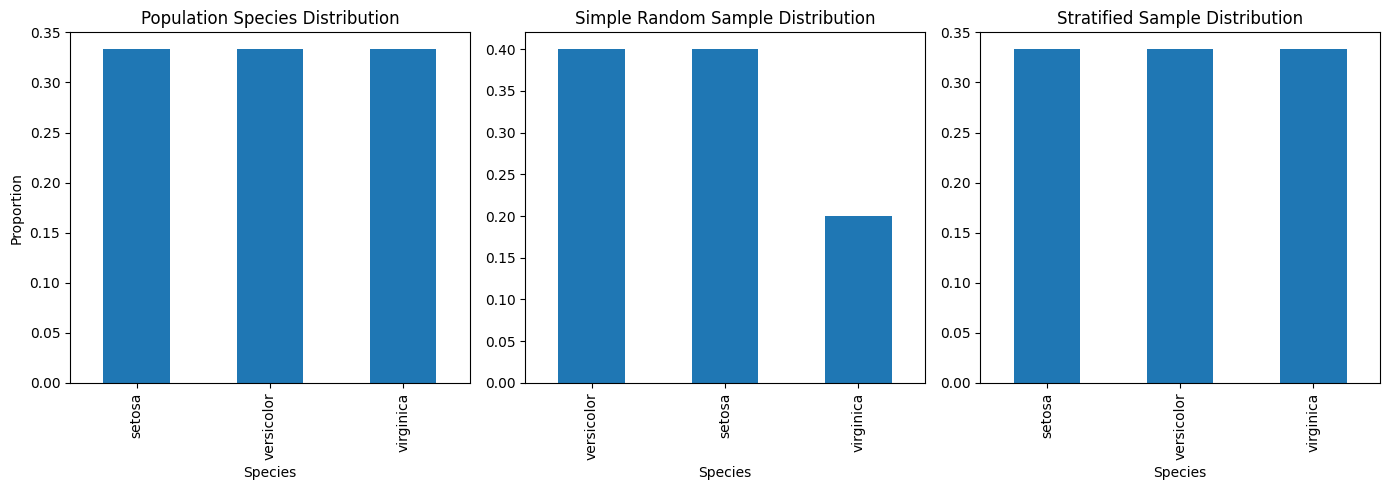

In [5]:
# 4. Visualization of Distributions
# -------------------------------------------------------------

plt.figure(figsize=(14,5))

# Population
plt.subplot(1,3,1)
population_dist.plot(kind='bar')
plt.title("Population Species Distribution")
plt.xlabel("Species")
plt.ylabel("Proportion")

# Simple Random Sample
plt.subplot(1,3,2)
simple_dist.plot(kind='bar')
plt.title("Simple Random Sample Distribution")
plt.xlabel("Species")

# Stratified Sample
plt.subplot(1,3,3)
stratified_dist.plot(kind='bar')
plt.title("Stratified Sample Distribution")
plt.xlabel("Species")

plt.tight_layout()
plt.show()